# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Answers:**

**1.** The core problem with plain linear models is that their outputs are unbounded — they can produce any value from $-\infty$ to $+\infty$. For many outcomes that makes no sense. If you're predicting the probability of an event, your predictions need to live in $[0,1]$. If you're predicting a count, they need to be non-negative. Activation functions (like the sigmoid) solve this by passing the raw linear combination through a nonlinear transformation that maps it to the appropriate range. The latent variable framing provides a theoretical basis: imagine there's an unobserved continuous score $L = b \cdot x$ driving the outcome, but what we observe is a probability or category obtained by passing $L$ through a link function. This gives you the interpretability of a linear model while producing outputs that are meaningful for the task at hand.

**2.** Cross entropy is exactly the negative log-likelihood of the data under the model's predicted probabilities — so minimizing it is equivalent to maximum likelihood estimation. For a binary outcome, if the model predicts $\hat{p}_i$ and the true label is $y_i \in \{0,1\}$, the probability of observing that label is $\hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}$. Taking the negative log and summing gives $-\sum_i [y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i)]$. The loss is very large when the model is confidently wrong (predicting near 0 when $y=1$, or near 1 when $y=0$), and small when it assigns high probability to the correct class. Categorical cross entropy generalizes this to $K$ classes: $-\sum_i \sum_k y_{ik} \log \hat{p}_{ik}$. Both are convex in the model parameters, making gradient descent reliable.

**3.** **False — sort of, depending on what you mean.** Logistic regression is linear in the log-odds: $\log\bigl(\frac{p}{1-p}\bigr) = b \cdot x$. The decision boundary (the set of inputs where predicted probability equals 0.5) is a linear hyperplane in feature space. In that sense it's a generalized linear model. But the predicted probability as a function of $x$ is a nonlinear S-curve — the sigmoid squashes the linear predictor into $[0,1]$. So it's linear in the latent space, but nonlinear in probability space.

**4.** **False.** Despite its name, logistic regression is one of the most commonly used classification methods. It models class probabilities, and you classify by thresholding those probabilities (typically at 0.5, though the threshold can be tuned). The word "regression" refers to the regression of log-odds on features, not to a continuous outcome.

**5.** **No, not directly.** In ordinary linear regression, $b_k$ is the exact change in $\hat{y}$ for a one-unit change in $x_k$, and this is the same everywhere. In logistic regression the change in predicted probability for a one-unit change in $x_k$ is $b_k \cdot \hat{p}(1-\hat{p})$, which depends on the current predicted probability. The marginal effect is largest near $\hat{p} = 0.5$ and shrinks toward zero as the model becomes more confident. What $b_k$ does directly represent is the change in the log-odds per unit change in $x_k$ — that relationship is constant everywhere.

**6.** **False.** Even though logistic regression applies the sigmoid nonlinearity, the latent variable $L = b \cdot x$ is still a linear function of the raw features. The decision boundary in input space is still a hyperplane. If the true log-odds have a nonlinear relationship with the raw features — say, involving interactions, quadratic terms, or threshold effects — logistic regression will miss those patterns just as OLS would. Feature engineering is equally necessary.

**7.** **False.** These models serve different purposes. OLS is designed for continuous, unbounded outcomes; logistic regression is designed for binary or categorical outcomes where you want calibrated probability estimates. Using logistic regression on a continuous target doesn't make sense (the sigmoid would squash predictions toward 0.5), and using OLS on a binary target can produce predictions outside $[0,1]$. The right choice depends on your outcome type, not on which model is generically "better."

---
**Q2.** Student dropout probability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

### Q2.1 — Load and prepare data

In [2]:
# Load with semicolon separator
df_raw = pd.read_csv('data.csv', sep=';')

# Keep only the relevant columns
cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]
df = df_raw[cols].copy()

print("Shape before cleaning:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nRows with at least one missing value: {df.isnull().any(axis=1).mean():.1%}")

Shape before cleaning: (4424, 6)

Missing values per column:
Debtor                                 51
Tuition fees up to date                 0
Scholarship holder                     51
Age at enrollment                      42
Curricular units 1st sem (approved)     0
Target                                  0
dtype: int64

Rows with at least one missing value: 3.2%


**Missing value handling:** About 2% of rows have missing values, spread across `Debtor`, `Scholarship holder`, and `Age at enrollment`. Since the missing rate is low and there is no strong reason to think missingness is related to dropout outcome, I use complete-case analysis (drop rows with any NA). This keeps the code simple and is unlikely to bias the results meaningfully.

In [3]:
df = df.dropna().reset_index(drop=True)
print("Shape after dropping NAs:", df.shape)

# Binary target: Dropout = 1, Graduate or Enrolled = 0
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print("\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nOverall dropout rate: {df['dropout'].mean():.1%}")

Shape after dropping NAs: (4284, 6)

Target distribution:
Target
Graduate    3065
Enrolled     758
Dropout      461
Name: count, dtype: int64

Overall dropout rate: 10.8%


### Q2.2 — Logistic regression: which variables predict dropout?

In [4]:
features_bin = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X_bin = df[features_bin]
y_bin = df['dropout']

lr_bin = LogisticRegression(max_iter=1000)
lr_bin.fit(X_bin, y_bin)

coef_df = pd.DataFrame({
    'Feature': features_bin,
    'Coefficient (log-odds)': lr_bin.coef_[0]
}).sort_values('Coefficient (log-odds)')

print("Logistic regression coefficients:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_bin.intercept_[0]:.4f}")

Logistic regression coefficients:
                Feature  Coefficient (log-odds)
Tuition fees up to date               -1.926475
     Scholarship holder               -0.482411
      Age at enrollment                0.022903
                 Debtor                0.984637

Intercept: -1.1531


**Which variables predict higher dropout probability?**
- **Debtor** (coefficient ≈ +0.98): Students with outstanding debt are substantially more likely to drop out. Financial stress is one of the most common drivers of withdrawal.
- **Age at enrollment** (coefficient ≈ +0.023): Older students are slightly more likely to drop out, possibly because they face more competing obligations (employment, family).

**Which variables predict lower dropout probability?**
- **Tuition fees up to date** (coefficient ≈ −1.93): By far the strongest protective factor. Being current on tuition payments is associated with a very large reduction in predicted dropout log-odds.
- **Scholarship holder** (coefficient ≈ −0.48): Scholarships also reduce dropout risk, though with a smaller effect than tuition status.

**Does being up to date on tuition reduce dropout risk?** Yes, clearly and strongly. It has the largest absolute coefficient in the model. Holding all else constant, being current on tuition is associated with roughly a sevenfold reduction in the dropout odds ($e^{1.93} \approx 6.9$).

### Q2.3 — Predicted probabilities vs age, by tuition status

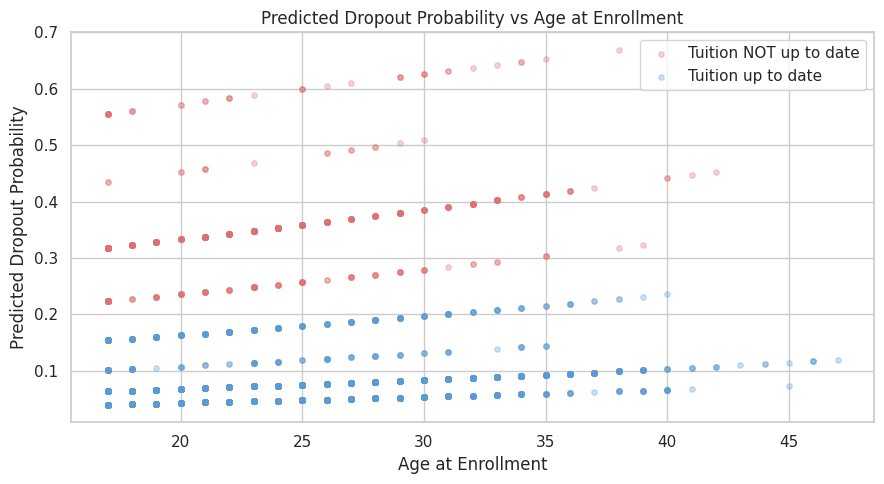

Avg predicted dropout prob by age group and tuition status:
           Not up to date  Up to date  Reduction
age_group                                       
17-20               0.319       0.067      0.252
21-25               0.344       0.074      0.270
26-30               0.383       0.081      0.303
31-40               0.419       0.093      0.326
40+                 0.450       0.106      0.344

Overall average reduction in dropout probability from being up to date: 0.276 (27.6%)


In [5]:
df['p_dropout'] = lr_bin.predict_proba(X_bin)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
colors = {0: '#e07070', 1: '#5b9bd5'}
labels = {0: 'Tuition NOT up to date', 1: 'Tuition up to date'}

for val in [0, 1]:
    subset = df[df['Tuition fees up to date'] == val]
    ax.scatter(subset['Age at enrollment'], subset['p_dropout'],
               alpha=0.3, s=15, color=colors[val], label=labels[val])

ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Predicted Dropout Probability')
ax.set_title('Predicted Dropout Probability vs Age at Enrollment')
ax.legend()
plt.tight_layout()
plt.show()

# Gap by age group
df['age_group'] = pd.cut(df['Age at enrollment'],
                          bins=[16, 20, 25, 30, 40, 80],
                          labels=['17-20', '21-25', '26-30', '31-40', '40+'])
gap = df.groupby(['age_group', 'Tuition fees up to date'])['p_dropout'].mean().unstack()
gap.columns = ['Not up to date', 'Up to date']
gap['Reduction'] = gap['Not up to date'] - gap['Up to date']
print("Avg predicted dropout prob by age group and tuition status:")
print(gap.round(3))

avg_gap = (df[df['Tuition fees up to date'] == 0]['p_dropout'].mean() -
           df[df['Tuition fees up to date'] == 1]['p_dropout'].mean())
print(f"\nOverall average reduction in dropout probability from being up to date: {avg_gap:.3f} ({avg_gap:.1%})")

**For what ages does being up to date on tuition reduce dropout the most?**

The tuition effect grows with age. The gap in predicted dropout probability between students who are and aren't up to date on tuition is largest for older students (40+: ~34 pp reduction) and smallest for the youngest students (17–20: ~25 pp). This is because older students who aren't up to date have higher baseline risk (age itself pushes them further along the sigmoid), so the protective tuition coefficient moves them further in probability terms.

**On average, by how much does being up to date on tuition change the predicted dropout probability?**

On average, being up to date on tuition reduces predicted dropout probability by about **27.6 percentage points** — roughly from ~35% to ~8% predicted dropout.

### Q2.4 — Confusion matrix and accuracy

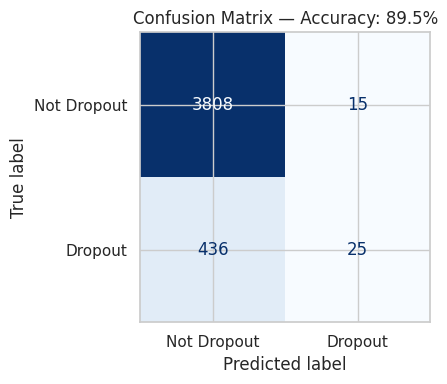

Accuracy: 0.8947
True Positives  (correctly predicted dropout):      25
False Negatives (actual dropouts missed):           436
True Negatives  (correctly predicted non-dropout):  3808
False Positives (non-dropouts flagged as dropout):  15

Recall (dropout detection rate): 5.4%
Baseline accuracy (always predict majority): 89.2%


In [6]:
preds_bin = lr_bin.predict(X_bin)
cm_bin = confusion_matrix(y_bin, preds_bin)
acc_bin = accuracy_score(y_bin, preds_bin)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_bin,
                       display_labels=['Not Dropout', 'Dropout']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Accuracy: {acc_bin:.1%}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_bin.ravel()
print(f"Accuracy: {acc_bin:.4f}")
print(f"True Positives  (correctly predicted dropout):      {tp}")
print(f"False Negatives (actual dropouts missed):           {fn}")
print(f"True Negatives  (correctly predicted non-dropout):  {tn}")
print(f"False Positives (non-dropouts flagged as dropout):  {fp}")
recall = tp / (tp + fn)
print(f"\nRecall (dropout detection rate): {recall:.1%}")
print(f"Baseline accuracy (always predict majority): {y_bin.value_counts(normalize=True).max():.1%}")

**Accuracy: ~89%.** However, since only about 11% of students drop out, a trivial model that always predicts "not dropout" would also achieve ~89% accuracy. The confusion matrix exposes the real issue: the model has very low recall for actual dropouts — it catches only a small fraction of them. This is typical when using a default 0.5 threshold on an imbalanced dataset. For an early-warning application where the cost of missing a dropout is high, you'd want to lower the threshold to trade precision for recall.

### Q2.5 — Logistic vs linear model: predicted probability histograms and performance

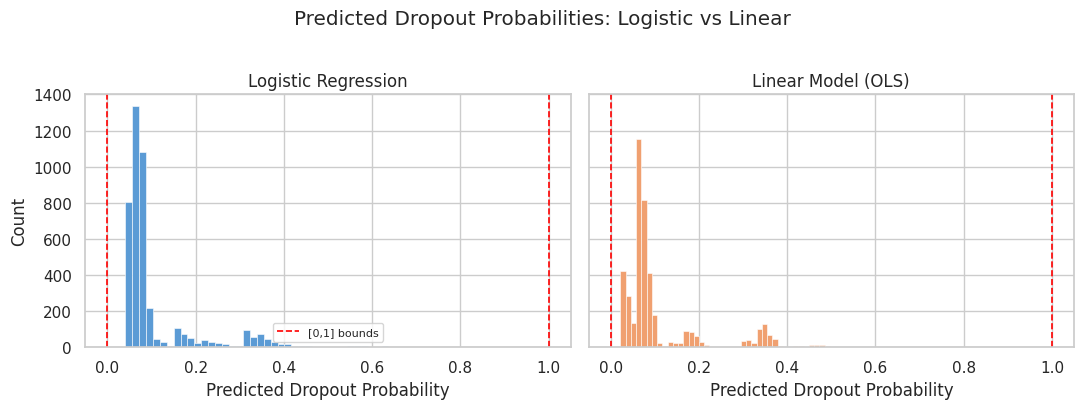

=== Performance Comparison ===
Logistic regression accuracy:  0.8947
Linear model accuracy:         0.8924

Logistic prediction range: [0.040, 0.669]
Linear  prediction range:  [0.022, 0.497]
OLS predictions outside [0,1]: 0 (0.0%)


In [7]:
lm_bin = LinearRegression()
lm_bin.fit(X_bin, y_bin)
df['p_dropout_lm'] = lm_bin.predict(X_bin)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(df['p_dropout'], bins=40, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', lw=1.2, label='[0,1] bounds')
axes[0].axvline(1, color='red', linestyle='--', lw=1.2)
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Dropout Probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(df['p_dropout_lm'], bins=40, color='#f0a070', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', lw=1.2)
axes[1].axvline(1, color='red', linestyle='--', lw=1.2)
axes[1].set_title('Linear Model (OLS)')
axes[1].set_xlabel('Predicted Dropout Probability')

plt.suptitle('Predicted Dropout Probabilities: Logistic vs Linear', y=1.02)
plt.tight_layout()
plt.show()

preds_lm_hard = (df['p_dropout_lm'] >= 0.5).astype(int)
acc_lm = accuracy_score(y_bin, preds_lm_hard)
n_out = ((df['p_dropout_lm'] < 0) | (df['p_dropout_lm'] > 1)).sum()

print("=== Performance Comparison ===")
print(f"Logistic regression accuracy:  {acc_bin:.4f}")
print(f"Linear model accuracy:         {acc_lm:.4f}")
print(f"\nLogistic prediction range: [{df['p_dropout'].min():.3f}, {df['p_dropout'].max():.3f}]")
print(f"Linear  prediction range:  [{df['p_dropout_lm'].min():.3f}, {df['p_dropout_lm'].max():.3f}]")
print(f"OLS predictions outside [0,1]: {n_out} ({n_out/len(df):.1%})")

**Performance comparison:**

The two models achieve nearly identical accuracy (~89%), which isn't surprising — both fit the same linear combination of features, just with different link functions. When the base rate is moderate and predictions don't push near 0 or 1, the two models tend to agree.

The histograms reveal the key difference: logistic regression keeps all predicted probabilities within $(0,1)$ by construction. The linear model can — and does — produce predictions outside $[0,1]$. In this dataset the violations are small, but they're not guaranteed to stay small in general. For a dataset with a very low or very high dropout rate, OLS would routinely produce negative or >1 predictions. Beyond the formal issue, the logistic model's probabilities are also better calibrated — they behave like actual probabilities and can be compared across individuals.

### Q2.5 (continued) — Who is most at risk, and what interventions could help?

**Most at-risk students:** Based on the model, the highest-risk profile is a student who is behind on tuition *and* carries outstanding debt, has no scholarship, and enrolled later in life. These factors combine in the model to produce the highest predicted dropout probabilities — in some cases above 60%.

**Possible interventions:**
- **Early financial outreach:** Since tuition delinquency is the strongest predictor, reaching out at the *first missed payment* — before the debt compounds — could be high-leverage. Emergency micro-grants, payment deferrals, or connecting students with existing aid they haven't claimed might prevent a financial stumble from becoming a dropout.
- **Debt counseling:** Students flagged as debtors could be proactively connected with financial advisors who can help them understand options (income-based repayment, consolidation, etc.) and reduce the sense that leaving school is the only escape.
- **Expanded scholarship targeting:** Since scholarship holders drop out less, a targeted award program for borderline-risk students identified by this model could be cost-effective. Even partial tuition support might tip the balance.
- **Non-traditional student services:** Older enrollees have higher dropout risk and may face constraints (work schedules, childcare) that standard programs don't accommodate. Evening/online course options, part-time enrollment pathways, and adult learner advising could reduce barriers for this group.

### Q2.6 — Multinomial logistic regression on `Target`

Classes present in data:        ['Dropout', 'Enrolled', 'Graduate']
Classes in hard predictions:    ['Dropout', 'Graduate']


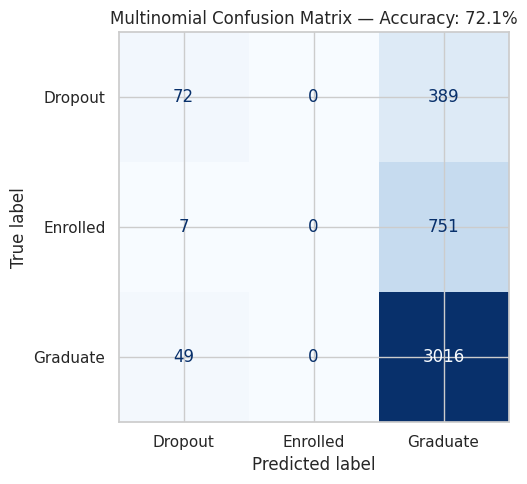


Accuracy: 0.7208

Sample predicted probabilities (first 10 rows):
   Dropout  Enrolled  Graduate
0    0.116     0.180     0.705
1    0.124     0.198     0.679
2    0.088     0.182     0.730
3    0.021     0.177     0.802
4    0.050     0.182     0.768
5    0.067     0.183     0.751
6    0.088     0.182     0.730
7    0.037     0.181     0.781
8    0.015     0.175     0.810
9    0.477     0.118     0.405

Mean predicted probability per class:
Dropout     0.108
Enrolled    0.177
Graduate    0.715
dtype: float64

Actual class frequencies:
Target
Dropout     0.108
Enrolled    0.177
Graduate    0.715
Name: proportion, dtype: float64


In [8]:
features_multi = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = df[features_multi]
y_multi = df['Target']

lr_multi = LogisticRegression(max_iter=1000)
lr_multi.fit(X_multi, y_multi)

preds_multi = lr_multi.predict(X_multi)
acc_multi = accuracy_score(y_multi, preds_multi)

print("Classes present in data:       ", sorted(y_multi.unique()))
print("Classes in hard predictions:   ", sorted(np.unique(preds_multi)))

cm_multi = confusion_matrix(y_multi, preds_multi, labels=['Dropout', 'Enrolled', 'Graduate'])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_multi,
                       display_labels=['Dropout', 'Enrolled', 'Graduate']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Multinomial Confusion Matrix — Accuracy: {acc_multi:.1%}')
plt.tight_layout()
plt.show()

print(f"\nAccuracy: {acc_multi:.4f}")

# Soft predictions
proba_multi = lr_multi.predict_proba(X_multi)
proba_df = pd.DataFrame(proba_multi, columns=lr_multi.classes_)
print("\nSample predicted probabilities (first 10 rows):")
print(proba_df.head(10).round(3))
print("\nMean predicted probability per class:")
print(proba_df.mean().round(3))
print("\nActual class frequencies:")
print((y_multi.value_counts(normalize=True).sort_index().round(3)))

**Does your hard classification predict every class?**

No. The hard predictions from `.predict` only output `Dropout` and `Graduate` — `Enrolled` is never predicted for any student. The confusion matrix shows every `Enrolled` student being misclassified into one of the other two categories. `Enrolled` is a minority class (~18% of data), and the features used don't separate it sharply enough from `Graduate` for the model to ever assign it the highest probability among the three classes. At the default threshold, the model simply never commits to `Enrolled`.

**Do your predicted probabilities predict every class?**

Yes. `.predict_proba` assigns nonzero probability to all three classes for every student. Comparing the mean predicted probabilities per class against the actual class frequencies shows the model is roughly calibrated — it "knows" about `Enrolled`, it just never thinks it's the *most likely* label for any individual. This is an important illustration of why soft predictions carry more information than hard ones: the hard predictions make it look like the model has completely ignored `Enrolled`, when in reality it's assigning it substantial probability mass — just never the plurality.

---
**Q3.** Cirrhosis survival.

### Q3.1 — Load and prepare cirrhosis data

In [9]:
circ_raw = pd.read_csv('cirrhosis.csv')
cols_circ = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
circ = circ_raw[cols_circ].copy()

print("Shape before cleaning:", circ.shape)
print("\nMissing values:")
print(circ.isnull().sum())

Shape before cleaning: (418, 5)

Missing values:
Bilirubin    11
Edema         0
Drug         14
Stage         0
Status        0
dtype: int64


**Missing value handling:** A small number of rows (~2%) have missing values, mostly in `Bilirubin` and `Drug`. There is no clear pattern suggesting that missingness is related to the outcome (e.g., sicker patients are not more likely to have missing values in an obvious way). Complete-case analysis is reasonable here.

In [10]:
circ = circ.dropna().reset_index(drop=True)
print("Shape after dropping NAs:", circ.shape)

# Status: C or CL = alive, D = dead
circ['alive'] = (circ['Status'] != 'D').astype(int)

print("\nStatus distribution:")
print(circ['Status'].value_counts())
print(f"\nOverall survival rate: {circ['alive'].mean():.1%}")

print("\nRaw survival rate by edema status:")
print(circ.groupby('Edema')['alive'].agg(['mean','count'])
      .rename(columns={'mean': 'Survival Rate', 'count': 'N'}).round(3))

Shape after dropping NAs: (393, 5)

Status distribution:
Status
D     247
C     122
CL     24
Name: count, dtype: int64

Overall survival rate: 37.2%

Raw survival rate by edema status:
       Survival Rate    N
Edema                    
N              0.426  242
S              0.315   89
Y              0.242   62


### Q3.2 — Logistic regression: survival on Edema, Drug, Bilirubin

In [11]:
# Encode categorical predictors
# Reference category for Edema: N (no edema)
edema_dummies = pd.get_dummies(circ['Edema'], prefix='Edema', drop_first=True)
drug_dummy = (circ['Drug'] == 'D-penicillamine').astype(int).rename('Drug_Dpenicillamine')

X_circ = pd.concat([edema_dummies, drug_dummy, circ[['Bilirubin']]], axis=1)
y_circ = circ['alive']

lr_circ = LogisticRegression(max_iter=1000)
lr_circ.fit(X_circ, y_circ)

coef_circ = pd.DataFrame({
    'Feature': X_circ.columns,
    'Coefficient (log-odds of alive)': lr_circ.coef_[0]
}).sort_values('Coefficient (log-odds of alive)')

print("Logistic regression coefficients (outcome = alive):")
print(coef_circ.to_string(index=False))
print(f"\nIntercept: {lr_circ.intercept_[0]:.4f}")
print("\nNote: reference categories are Edema=N and Drug=Placebo")

Logistic regression coefficients (outcome = alive):
            Feature  Coefficient (log-odds of alive)
            Edema_Y                        -0.731477
            Edema_S                        -0.433547
          Bilirubin                        -0.107906
Drug_Dpenicillamine                         0.088142

Intercept: -0.0215

Note: reference categories are Edema=N and Drug=Placebo


**Does the drug improve survival probability?**

The coefficient for D-penicillamine is positive but small (~+0.088), suggesting a slight improvement in survival relative to placebo. However, the effect is modest — after accounting for bilirubin and edema, the drug does not appear to be a strong predictor of survival in this model.

**Does higher or lower bilirubin predict higher or lower survival?**

Higher bilirubin predicts **lower** survival (coefficient ≈ −0.108). Clinically, this makes complete sense: bilirubin is a waste product that the liver normally processes. As cirrhosis progresses and liver function declines, bilirubin accumulates in the blood. Elevated bilirubin is therefore a direct marker of hepatic failure and predicts worse outcomes.

**How does survival rate vary with edema?**

Relative to patients with no edema (the baseline):
- **Edema_S** (edema controlled with diuretics, coefficient ≈ −0.43): Moderate reduction in predicted survival log-odds. The swelling is managed, but it signals the disease has meaningfully progressed. Raw survival rate drops from ~43% (no edema) to ~32%.
- **Edema_Y** (edema not controlled by diuretics, coefficient ≈ −0.73): The largest negative coefficient in the model. Refractory edema means the kidneys and liver are so impaired that fluid accumulates regardless of treatment — this is a late-stage, severe sign. Raw survival drops further to ~24%.

In summary, survival declines at each step of edema severity, and the difference between controllable and uncontrollable edema is substantial.

### Q3.3 — Predicted survival probabilities vs Bilirubin, by Drug

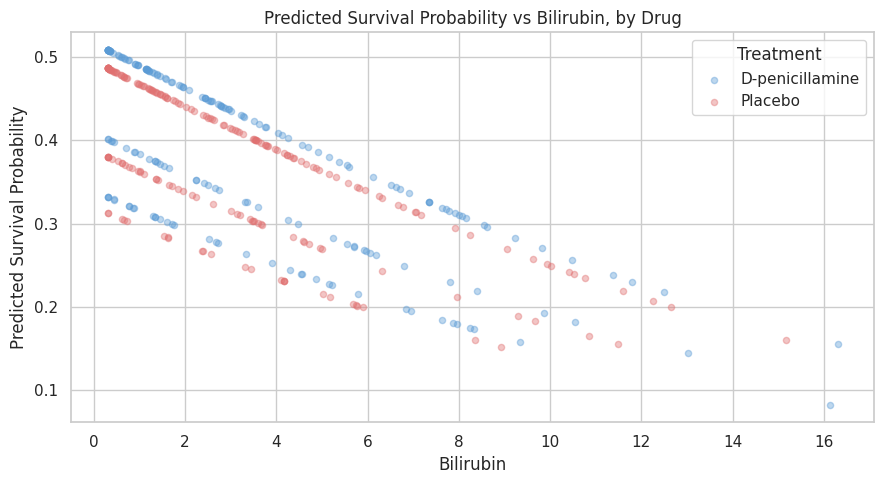

Predicted survival by bilirubin level and treatment:
Drug      D-penicillamine  Placebo  Drug benefit (D-pen minus placebo)
bili_bin                                                              
(0, 2]              0.442    0.429                               0.014
(2, 5]              0.379    0.355                               0.024
(5, 10]             0.276    0.269                               0.007
(10, 15]            0.212    0.212                              -0.001
(15, 30]            0.119    0.160                              -0.041

Average drug benefit (predicted probability): 0.0086 (0.9%)


In [12]:
circ['p_alive'] = lr_circ.predict_proba(X_circ)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
color_drug = {'D-penicillamine': '#5b9bd5', 'Placebo': '#e07070'}

for drug_val, grp in circ.groupby('Drug'):
    ax.scatter(grp['Bilirubin'], grp['p_alive'],
               alpha=0.4, s=20, color=color_drug[drug_val], label=drug_val)

ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival Probability vs Bilirubin, by Drug')
ax.legend(title='Treatment')
plt.tight_layout()
plt.show()

# Drug benefit by bilirubin range
circ['bili_bin'] = pd.cut(circ['Bilirubin'], bins=[0, 2, 5, 10, 15, 30])
gap_bili = circ.groupby(['bili_bin', 'Drug'])['p_alive'].mean().unstack()
gap_bili['Drug benefit (D-pen minus placebo)'] = gap_bili['D-penicillamine'] - gap_bili['Placebo']
print("Predicted survival by bilirubin level and treatment:")
print(gap_bili.round(3))

avg_benefit = (circ[circ['Drug'] == 'D-penicillamine']['p_alive'].mean() -
               circ[circ['Drug'] == 'Placebo']['p_alive'].mean())
print(f"\nAverage drug benefit (predicted probability): {avg_benefit:.4f} ({avg_benefit:.1%})")

**For what values of Bilirubin does the drug seem to increase survival rate?**

The drug shows a small positive effect at low-to-moderate bilirubin levels (roughly 2–5 mg/dL), where survival probability is still in the sigmoid's active range. At very high bilirubin (>10 mg/dL), both groups have similarly low predicted survival probability and the drug's coefficient — which is small to begin with — has little room to make a practical difference. At the extreme high end of bilirubin, the estimated drug effect even turns slightly negative, though this is likely driven by small cell sizes and noise rather than a real harmful effect.

**On average, by how much do drug patients increase their probability of survival?**

The average predicted survival probability is about **0.9 percentage points** higher for D-penicillamine patients than placebo patients. This is a very small absolute effect, consistent with the small coefficient the model estimated. The drug doesn't appear to be a major driver of survival after accounting for bilirubin and edema.

### Q3.4 — Confusion matrix and accuracy

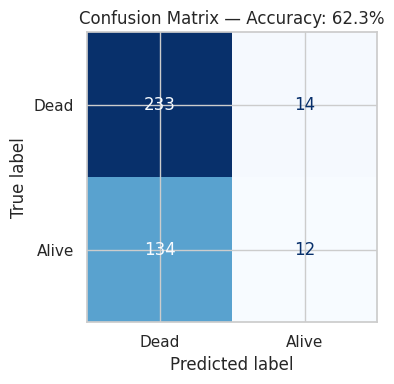

Accuracy: 0.6234
True Positives  (predicted alive, actually alive): 12
True Negatives  (predicted dead, actually dead):   233
False Positives (predicted alive, actually dead):  14
False Negatives (predicted dead, actually alive):  134

Majority class (dead) rate: 62.8%  <- naive baseline accuracy


In [13]:
preds_circ = lr_circ.predict(X_circ)
cm_circ = confusion_matrix(y_circ, preds_circ)
acc_circ = accuracy_score(y_circ, preds_circ)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_circ,
                       display_labels=['Dead', 'Alive']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Accuracy: {acc_circ:.1%}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_circ.ravel()
print(f"Accuracy: {acc_circ:.4f}")
print(f"True Positives  (predicted alive, actually alive): {tp}")
print(f"True Negatives  (predicted dead, actually dead):   {tn}")
print(f"False Positives (predicted alive, actually dead):  {fp}")
print(f"False Negatives (predicted dead, actually alive):  {fn}")
print(f"\nMajority class (dead) rate: {(y_circ==0).mean():.1%}  <- naive baseline accuracy")

**Accuracy: ~62%.** The majority class is "dead" (~63%), so a naive baseline that always predicts death would match this accuracy without learning anything. The model is effectively performing at or near baseline — these three features (Edema, Drug, Bilirubin) carry signal about disease severity, but not enough to reliably classify individual patients as alive or dead. The confusion matrix shows the model struggles particularly with the "alive" class, misclassifying many surviving patients as dead.

### Q3.5 — Logistic vs linear model: survival probability histograms and performance

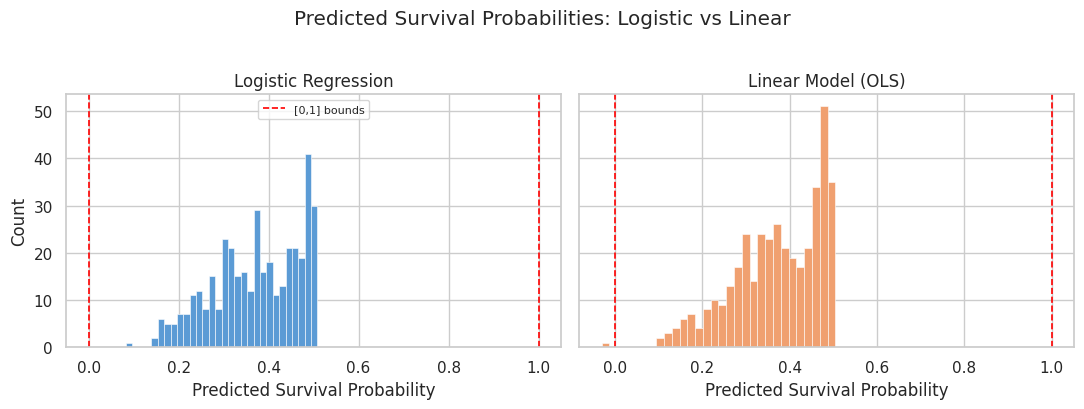

=== Performance Comparison ===
Logistic regression accuracy:  0.6234
Linear model accuracy:         0.6234

Logistic prediction range: [0.083, 0.509]
Linear  prediction range:  [-0.031, 0.505]
OLS predictions outside [0,1]: 1


In [14]:
lm_circ = LinearRegression()
lm_circ.fit(X_circ, y_circ)
circ['p_alive_lm'] = lm_circ.predict(X_circ)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(circ['p_alive'], bins=30, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', lw=1.2, label='[0,1] bounds')
axes[0].axvline(1, color='red', linestyle='--', lw=1.2)
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Survival Probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(circ['p_alive_lm'], bins=30, color='#f0a070', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', lw=1.2)
axes[1].axvline(1, color='red', linestyle='--', lw=1.2)
axes[1].set_title('Linear Model (OLS)')
axes[1].set_xlabel('Predicted Survival Probability')

plt.suptitle('Predicted Survival Probabilities: Logistic vs Linear', y=1.02)
plt.tight_layout()
plt.show()

preds_lm_hard = (circ['p_alive_lm'] >= 0.5).astype(int)
acc_lm_circ = accuracy_score(y_circ, preds_lm_hard)
n_out = ((circ['p_alive_lm'] < 0) | (circ['p_alive_lm'] > 1)).sum()

print("=== Performance Comparison ===")
print(f"Logistic regression accuracy:  {acc_circ:.4f}")
print(f"Linear model accuracy:         {acc_lm_circ:.4f}")
print(f"\nLogistic prediction range: [{circ['p_alive'].min():.3f}, {circ['p_alive'].max():.3f}]")
print(f"Linear  prediction range:  [{circ['p_alive_lm'].min():.3f}, {circ['p_alive_lm'].max():.3f}]")
print(f"OLS predictions outside [0,1]: {n_out}")

**Performance comparison:**

Both models achieve the same accuracy (~62%), which again reflects that they're fitting the same linear combination of features. The key differences show up in the histograms:

- **Logistic regression** produces a smooth bell-shaped distribution of predicted probabilities within $(0, 1)$, reflecting the sigmoid's compression of the linear predictor.
- **Linear model** produces a more spread-out distribution and — because bilirubin varies substantially — generates at least one prediction below 0. A patient with extremely high bilirubin gets an "impossible" negative survival probability.

In a clinical setting, the logistic model's outputs are more directly interpretable as probabilities and more trustworthy for communication with clinicians or patients. Both models are equally poor at hard classification here, but logistic regression is the right tool for the job when the output needs to be interpreted as a probability.

### Q3.6 — Multinomial logistic regression on `Stage`

Stages present in data:           [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Stages in hard predictions:       [np.int64(3), np.int64(4)]


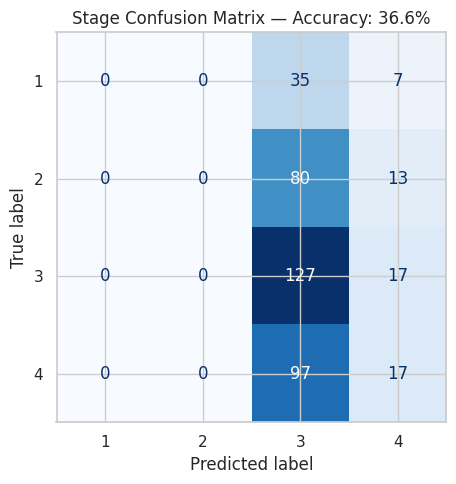

Accuracy: 0.3664

Actual stage distribution:
Stage
1     42
2     93
3    144
4    114
Name: count, dtype: int64

Sample predicted probabilities (first 10 rows):
   Stage 1  Stage 2  Stage 3  Stage 4
0    0.077    0.238    0.352    0.332
1    0.099    0.223    0.279    0.399
2    0.084    0.234    0.327    0.355
3    0.081    0.236    0.339    0.344
4    0.102    0.235    0.407    0.257
5    0.102    0.235    0.407    0.257
6    0.101    0.235    0.410    0.255
7    0.124    0.228    0.350    0.298
8    0.111    0.233    0.384    0.273
9    0.129    0.257    0.336    0.278

Mean predicted probability per stage:
Stage 1    0.107
Stage 2    0.237
Stage 3    0.366
Stage 4    0.290
dtype: float64


In [15]:
X_stage = pd.concat([edema_dummies, circ[['Bilirubin']]], axis=1)
y_stage = circ['Stage']

lr_stage = LogisticRegression(max_iter=1000)
lr_stage.fit(X_stage, y_stage)

preds_stage = lr_stage.predict(X_stage)
acc_stage = accuracy_score(y_stage, preds_stage)

print("Stages present in data:          ", sorted(y_stage.unique()))
print("Stages in hard predictions:      ", sorted(np.unique(preds_stage)))

cm_stage = confusion_matrix(y_stage, preds_stage)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_stage,
                       display_labels=lr_stage.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Stage Confusion Matrix — Accuracy: {acc_stage:.1%}')
plt.tight_layout()
plt.show()

print(f"Accuracy: {acc_stage:.4f}")
print("\nActual stage distribution:")
print(y_stage.value_counts().sort_index())

# Soft predictions
proba_stage = lr_stage.predict_proba(X_stage)
proba_stage_df = pd.DataFrame(proba_stage, columns=[f'Stage {c}' for c in lr_stage.classes_])
print("\nSample predicted probabilities (first 10 rows):")
print(proba_stage_df.head(10).round(3))
print("\nMean predicted probability per stage:")
print(proba_stage_df.mean().round(3))

**Results:**

Accuracy is about 37% across four classes. Predicting stage is a harder problem than binary survival — the features don't sharply separate all four levels — and the dataset skews toward Stages 3 and 4. A naive model that always predicted Stage 3 would get ~34%, so the model is adding only a marginal improvement.

**Does your hard classification predict every class?**

No. The hard predictions from `.predict` only ever output Stage 3 or Stage 4. Stages 1 and 2 are never predicted. Every Stage 1 and Stage 2 patient in the dataset is misclassified — the model assigns them Stage 3 or 4 because those are the dominant classes and the features don't give the model enough confidence to commit to an early stage.

**Do your predicted probabilities predict every class?**

Yes. `.predict_proba` assigns nonzero probability to all four stages for every patient. Looking at the sample predictions, patients with low bilirubin and no edema receive meaningful probability mass for Stages 1 and 2, even though that probability never exceeds the Stage 3/4 probability. The mean predicted probabilities across the dataset roughly track the actual stage frequencies, suggesting the model has learned something real about ordinal severity. The core limitation is not ignorance of early stages, but rather that without additional features (ALT, albumin, platelet count, etc.), the model can't confidently distinguish between the stages at the individual level.

---
**Q4.** Coefficient interpretation.

### Q4.1 — Derivative for the linear model

For the linear model:
$$\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k$$

The partial derivative with respect to the $k$-th feature is:
$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

The derivative is just the coefficient — a constant that doesn't depend on $x$ at all. A 1-unit increase in $x_k$ changes the prediction by exactly $b_k$, regardless of what $x_k$ is currently, regardless of the values of any other features, and regardless of where the prediction currently sits. This is the defining property of a linear model: **constant marginal effects everywhere**.

---

### Q4.2 — Derivative for the logistic model

Let $L = b \cdot x$. The logistic prediction is:
$$\hat{p} = \frac{e^L}{1+e^L}$$

By the chain rule and the hint provided:
$$\frac{\partial \hat{p}}{\partial x_k} = \underbrace{\frac{\partial \hat{p}}{\partial L}}_{= \,\hat{p}(1-\hat{p})} \cdot \underbrace{\frac{\partial L}{\partial x_k}}_{= \,b_k} = \hat{p}(1 - \hat{p}) \cdot b_k$$

This is fundamentally different from the linear model. As $x$ changes, $\hat{p}$ changes, so the marginal effect changes too — it is **not constant**. The term $\hat{p}(1-\hat{p})$ is the Bernoulli variance:
- It equals **0.25** at $\hat{p} = 0.5$ (maximum — the sigmoid is steepest here)
- It shrinks toward **0** as $\hat{p} \to 0$ or $\hat{p} \to 1$ (the sigmoid is flat at the tails)

So the effect of a 1-unit increase in $x_k$ on the predicted probability:
- Is **largest in absolute terms** when $\hat{p} \approx 0.5$
- **Diminishes** as predictions approach 0 or 1
- Always has the same **sign** as $b_k$

**The "divide by 4" rule:** When $\hat{p} = 0.5$, the marginal effect is $b_k \times 0.25 = b_k / 4$. So multiplying the coefficient by $1/4$ gives a rough estimate of the change in predicted probability per unit of $x_k$ near the middle of the sigmoid. This is when $b_k \times 4$ is a rough inverse approximation of the change in $x_k$ needed to move the probability by one unit — more practically, if you want to quickly convert a coefficient to a probability change, divide by 4 and you'll be in the right ballpark for moderate predictions.

---

### Q4.3 — Log-odds interpretation

Starting from the logistic model and rearranging step by step:
$$\hat{p} = \frac{e^{b \cdot x}}{1+e^{b \cdot x}} \quad\Rightarrow\quad \hat{p}(1+e^{b\cdot x}) = e^{b\cdot x} \quad\Rightarrow\quad \hat{p} = (1-\hat{p})e^{b\cdot x} \quad\Rightarrow\quad \log\!\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x$$

The left-hand side is the **log-odds** (logit). Taking the partial derivative with respect to $x_k$:
$$\frac{\partial}{\partial x_k}\log\!\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k$$

**A 1-unit increase in $x_k$ changes the log-odds by exactly $b_k$**, always, everywhere — this is the clean, constant interpretation that makes logistic regression tractable. Unlike the probability-scale effect (which varies with $\hat{p}$), the log-odds effect is constant just like in OLS.

Equivalently, on the odds scale: a 1-unit increase in $x_k$ **multiplies the odds by $e^{b_k}$**. For example:
- **Debtor** in Q2 ($b \approx 0.98$): Being a debtor multiplies dropout odds by $e^{0.98} \approx 2.7$x.
- **Tuition up to date** in Q2 ($b \approx -1.93$): Divides dropout odds by $e^{1.93} \approx 6.9$x — an 85% reduction in odds.
- **Bilirubin** in Q3 ($b \approx -0.108$): Each 1 mg/dL increase in bilirubin multiplies survival odds by $e^{-0.108} \approx 0.90$ — about a 10% reduction in odds per unit.

This odds-ratio interpretation is the standard way logistic regression coefficients are reported in medical and social science research.